<a href="https://colab.research.google.com/github/Gursharan-Reddy/InterSpark-Data-Science-Internship/blob/main/Task3_Instagram_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bhanupratapbiswas/instgram")

print("Path to dataset files:", path)

100%|██████████| 151k/151k [00:00<00:00, 24.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/bhanupratapbiswas/instgram/versions/1


Using Colab cache for faster access to the 'instgram' dataset.
Dataset loaded successfully!

--- Cleaned Columns ---
['id', 'comment', 'user_id', 'photo_id', 'created_timestamp', 'posted_date', 'emoji_used', 'hashtags_used_count']

Successfully parsed 0 dates out of 7488 total rows.

Skipping Time Charts: Dataset dates are in an unrecognizable format.


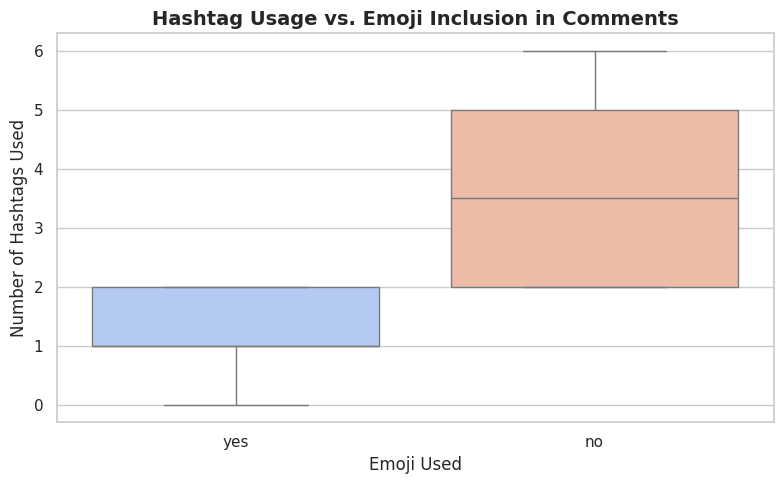

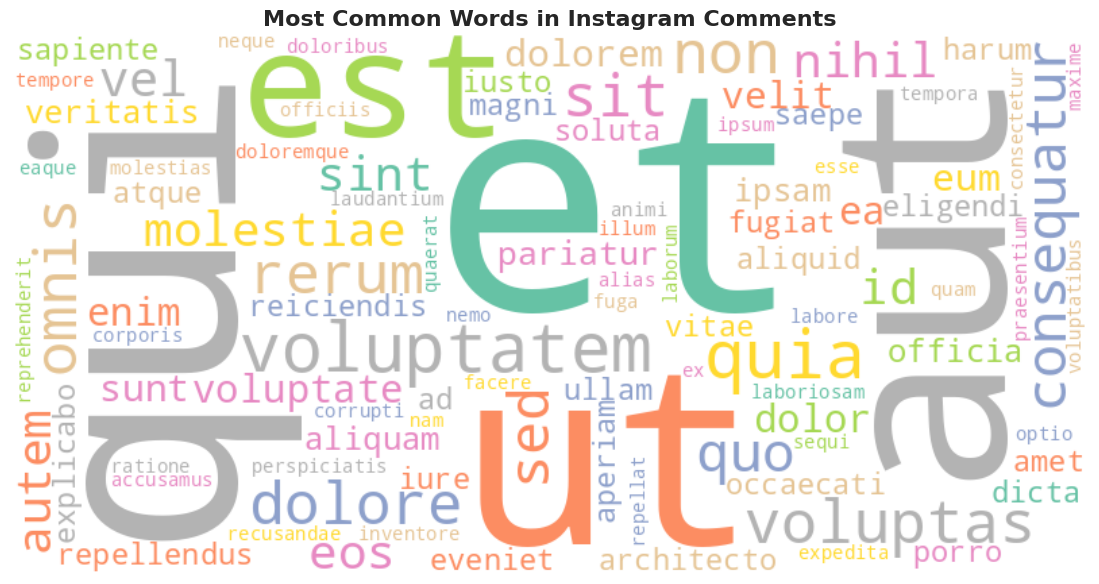

In [2]:
# 1. IMPORT LIBRARIES AND DATASET
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import os
import warnings
warnings.filterwarnings('ignore')

# Download and load the dataset
print("Downloading Instagram dataset...")
path = kagglehub.dataset_download("bhanupratapbiswas/instgram")
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

if csv_files:
    csv_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(csv_path, encoding='latin1')
    print("Dataset loaded successfully!\n")
else:
    print("Error: No CSV file found.")

# ---------------------------------------------------------
# 2. DATA PREPROCESSING & FEATURE ENGINEERING

# Clean columns
df.columns = df.columns.str.lower().str.strip().str.replace(r'\s+', '_', regex=True)
print("--- Cleaned Columns ---")
print(df.columns.tolist())

# SAFE DATE PARSING (Will not delete your main data!)
if 'created_timestamp' in df.columns:
    df['datetime'] = pd.to_datetime(df['created_timestamp'], unit='s', errors='coerce')

if 'datetime' not in df.columns or df['datetime'].isna().all():
    if 'posted_date' in df.columns:
        df['datetime'] = pd.to_datetime(df['posted_date'], errors='coerce')

df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.day_name()

valid_dates = df['datetime'].notna().sum()
print(f"\nSuccessfully parsed {valid_dates} dates out of {len(df)} total rows.")

# ---------------------------------------------------------
# 3. VISUALIZATIONS & ANALYSIS
sns.set_theme(style="whitegrid")

# Visualization 1 & 2: Time Charts (Only run if we actually have dates)
if valid_dates > 0:
    plt.figure(figsize=(10, 5))
    sns.countplot(x='hour', data=df.dropna(subset=['hour']), palette='viridis')
    plt.title('Audience Activity: Comment Volume by Hour of Day', fontsize=14, fontweight='bold')
    plt.xlabel('Hour of Day (24H Format)')
    plt.ylabel('Total Comments')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    sns.countplot(x='day_of_week', data=df.dropna(subset=['day_of_week']), order=days_order, palette='magma')
    plt.title('Audience Activity: Comment Volume by Day of Week', fontsize=14, fontweight='bold')
    plt.xlabel('Day of the Week')
    plt.ylabel('Total Comments')
    plt.tight_layout()
    plt.show()
else:
    print("\nSkipping Time Charts: Dataset dates are in an unrecognizable format.")

# Visualization 3: Emojis vs. Hashtags (Will work regardless of dates)
if 'emoji_used' in df.columns and 'hashtags_used_count' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='emoji_used', y='hashtags_used_count', data=df, palette='coolwarm')
    plt.title('Hashtag Usage vs. Emoji Inclusion in Comments', fontsize=14, fontweight='bold')
    plt.xlabel('Emoji Used')
    plt.ylabel('Number of Hashtags Used')
    plt.tight_layout()
    plt.show()

# Visualization 4: WordCloud of Comments (Will work regardless of dates)
if 'comment' in df.columns:
    plt.figure(figsize=(12, 6))
    comments_text = " ".join(str(comment) for comment in df['comment'].dropna() if str(comment).lower() != 'nan')

    if comments_text.strip():
        wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Set2', max_words=100).generate(comments_text)
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis("off")
        plt.title('Most Common Words in Instagram Comments', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()